# First Load the .graphml files

In [43]:
from pathlib import Path
import networkx as nx

folder_path = Path(".\\asnr datasets")
print(folder_path.exists())


asnr_graphs = {}

for file_path in folder_path.glob('*.graphml'):
    graph = nx.read_graphml(file_path)

    key_name = file_path.stem + ".graphml"

    asnr_graphs[key_name] = graph


True


In [44]:
print(asnr_graphs.keys())

dict_keys(['Network_0.graphml', 'Network_1.graphml', 'Network_10.graphml', 'Network_100.graphml', 'Network_1000.graphml', 'Network_1001.graphml', 'Network_1002.graphml', 'Network_1003.graphml', 'Network_1004.graphml', 'Network_1005.graphml', 'Network_1006.graphml', 'Network_1007.graphml', 'Network_1008.graphml', 'Network_1009.graphml', 'Network_101.graphml', 'Network_1010.graphml', 'Network_1011.graphml', 'Network_1012.graphml', 'Network_1013.graphml', 'Network_1014.graphml', 'Network_1015.graphml', 'Network_1016.graphml', 'Network_1017.graphml', 'Network_1018.graphml', 'Network_1019.graphml', 'Network_102.graphml', 'Network_1020.graphml', 'Network_1021.graphml', 'Network_1022.graphml', 'Network_1023.graphml', 'Network_1024.graphml', 'Network_1025.graphml', 'Network_1026.graphml', 'Network_1027.graphml', 'Network_1028.graphml', 'Network_1029.graphml', 'Network_103.graphml', 'Network_1030.graphml', 'Network_1031.graphml', 'Network_1032.graphml', 'Network_1033.graphml', 'Network_1034.gra

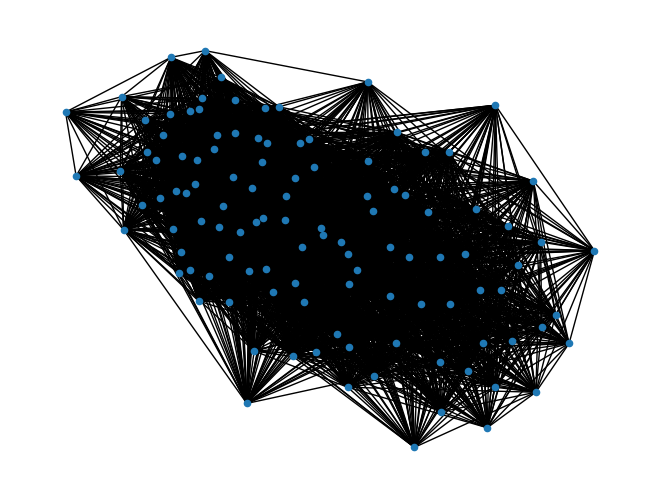

In [45]:
nx.draw(
    asnr_graphs["Network_9.graphml"],
    node_size=20
)

In [46]:
import pandas as pd

graph_info_file = ".\\asnr datasets\\Network_summary_masterfile.csv"

info_frame = pd.read_csv(graph_info_file)

print(info_frame.iloc[0])

Network_ID                                                      Network_0.graphml
Network_Identifiers                                         ant mersch col1 day01
class                                                                     Insecta
genus                                                                  Camponotus
species                                                                    fellah
interaction_type                                                 physical_contact
definition_of_interaction       A pair of ants was considered to interact when...
edge_wt_type                                                            frequency
geographical_location               University of Lausanne, Laussane, Switzerland
population_type                                                           captive
data_record_technique                                                       video
time_span                                                                    1day
resolution      

# Set up new DataFrame

In [49]:
import torch
from torch_geometric.data import Data

dataset = []

for key, graph in asnr_graphs.items():
    # Get label from DataFrame
    label = info_frame.loc[info_frame['Network_ID'] == key, 'class'].values[0]
    
    # Map nodes to integer indices
    node_mapping = {node: i for i, node in enumerate(graph.nodes())}
    
    # Node features: degree of each node
    x = torch.tensor([[graph.degree(node)] for node in graph.nodes()], dtype=torch.float)
    
    # Edge indices using integer mapping
    edges = [(node_mapping[u], node_mapping[v]) for u, v in graph.edges()]
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    
    # Graph label: convert string label to integer
    class_mapping = {c: i for i, c in enumerate(info_frame['class'].unique())}
    y = torch.tensor([class_mapping[label]], dtype=torch.long)
    
    data = Data(x=x, edge_index=edge_index, y=y)
    dataset.append(data)

In [62]:
print(dataset[:])
class_counts = info_frame['class'].value_counts()
print(class_counts)

[Data(x=[113, 1], edge_index=[2, 4550], y=[1]), Data(x=[113, 1], edge_index=[2, 4573], y=[1]), Data(x=[113, 1], edge_index=[2, 3454], y=[1]), Data(x=[141, 1], edge_index=[2, 6417], y=[1]), Data(x=[6, 1], edge_index=[2, 10], y=[1]), Data(x=[7, 1], edge_index=[2, 8], y=[1]), Data(x=[16, 1], edge_index=[2, 118], y=[1]), Data(x=[16, 1], edge_index=[2, 120], y=[1]), Data(x=[16, 1], edge_index=[2, 48], y=[1]), Data(x=[16, 1], edge_index=[2, 38], y=[1]), Data(x=[28, 1], edge_index=[2, 373], y=[1]), Data(x=[28, 1], edge_index=[2, 377], y=[1]), Data(x=[28, 1], edge_index=[2, 87], y=[1]), Data(x=[28, 1], edge_index=[2, 71], y=[1]), Data(x=[141, 1], edge_index=[2, 6368], y=[1]), Data(x=[73, 1], edge_index=[2, 142], y=[1]), Data(x=[62, 1], edge_index=[2, 334], y=[1]), Data(x=[216, 1], edge_index=[2, 755], y=[1]), Data(x=[95, 1], edge_index=[2, 1080], y=[1]), Data(x=[108, 1], edge_index=[2, 1622], y=[1]), Data(x=[29, 1], edge_index=[2, 148], y=[1]), Data(x=[27, 1], edge_index=[2, 26], y=[1]), Data(

In [60]:
for key in list(asnr_graphs.keys())[:100]:
    label_str = info_frame.loc[info_frame['Network_ID'] == key, 'class'].values[0]
    print(key, label_str, class_mapping[label_str])

Network_0.graphml Insecta 0
Network_1.graphml Insecta 0
Network_10.graphml Insecta 0
Network_100.graphml Insecta 0
Network_1000.graphml Mammalia 1
Network_1001.graphml Mammalia 1
Network_1002.graphml Mammalia 1
Network_1003.graphml Mammalia 1
Network_1004.graphml Mammalia 1
Network_1005.graphml Mammalia 1
Network_1006.graphml Mammalia 1
Network_1007.graphml Mammalia 1
Network_1008.graphml Mammalia 1
Network_1009.graphml Mammalia 1
Network_101.graphml Insecta 0
Network_1010.graphml Mammalia 1
Network_1011.graphml Mammalia 1
Network_1012.graphml Mammalia 1
Network_1013.graphml Mammalia 1
Network_1014.graphml Mammalia 1
Network_1015.graphml Mammalia 1
Network_1016.graphml Mammalia 1
Network_1017.graphml Mammalia 1
Network_1018.graphml Mammalia 1
Network_1019.graphml Reptilia 4
Network_102.graphml Insecta 0
Network_1020.graphml Reptilia 4
Network_1021.graphml Reptilia 4
Network_1022.graphml Reptilia 4
Network_1023.graphml Mammalia 1
Network_1024.graphml Mammalia 1
Network_1025.graphml Mamm

## GCN Implementation